# 🍌 Banana Leaf Disease Detection — Phase 2: LoRA Fine-Tuning

**Strategy:**
- Load LLaVA-1.5-7B in **bfloat16** to save VRAM
- Freeze all base model weights
- Attach **LoRA adapters** to attention + feed-forward layers
- Add a **3-class linear classification head** on top of the LLM hidden states
- Train only: LoRA adapters + classification head
- Use same 70/15/15 split from Phase 1

**Target: >90% test accuracy**

**Phase 1 baseline to beat: (your best zero-shot % from Phase 1)**

**Classes: HEALTHY | CMV | SIGATOKA**

## Step 0 — Runtime Check
Must be: **A100 GPU + High-RAM**
Runtime → Change runtime type → A100, High-RAM

In [ ]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)
import psutil
print(f"System RAM: {psutil.virtual_memory().total / (1024**3):.1f} GB")

Sun Mar  1 16:35:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   32C    P0             50W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
!pip uninstall bitsandbytes -y

## Step 1 — Install Dependencies

In [ ]:
%%capture
!pip install "transformers==4.40.0" "tokenizers==0.19.1" "accelerate==0.30.0" \
             "peft==0.10.0" \
             Pillow tqdm scikit-learn matplotlib seaborn pandas

## Step 2 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 3 — Configuration

In [ ]:
# ============================================================
#   USER CONFIG — Edit this section
# ============================================================

# Dataset root (same as Phase 1)
DATASET_ROOT = "/content/drive/MyDrive/FINAL_DATASET_CROP_MONITORING"  # <--- YOUR PATH

# Phase 1 split CSVs — point to your saved CSVs from Phase 1 output folder
# If you don't have them, set all three to None and splits will be regenerated
TRAIN_CSV = None   # e.g. "/content/drive/MyDrive/llava7b_banana_zeroshot_results_XXXX/train_split.csv"
VAL_CSV   = None   # e.g. "/content/drive/MyDrive/llava7b_banana_zeroshot_results_XXXX/val_split.csv"
TEST_CSV  = None   # e.g. "/content/drive/MyDrive/llava7b_banana_zeroshot_results_XXXX/test_split.csv"

# Model
MODEL_ID  = "llava-hf/llava-1.5-7b-hf"

# Output directory in Drive
OUTPUT_DIR = "/content/drive/MyDrive/llava_banana_phase2_output"

# ---- LoRA config ----
LORA_R         = 16
LORA_ALPHA     = 32
LORA_DROPOUT   = 0.05

# ---- Training config ----
NUM_EPOCHS     = 10
BATCH_SIZE     = 8       # per-step batch size
GRAD_ACCUM     = 2       # effective batch = BATCH_SIZE * GRAD_ACCUM = 16
LEARNING_RATE  = 2e-4
HEAD_LR        = 1e-3    # classification head learns faster
WARMUP_STEPS   = 100
WEIGHT_DECAY   = 0.01
EARLY_STOP_PATIENCE = 3  # stop if val acc doesn't improve for 3 epochs

# ---- Data ----
IMAGE_SIZE  = 336        # LLaVA-1.5 input size
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
SEED        = 42

CLASS_LABELS  = ["HEALTHY", "CMV", "SIGATOKA"]
LABEL_TO_IDX  = {label: i for i, label in enumerate(CLASS_LABELS)}
NUM_CLASSES   = len(CLASS_LABELS)

# Phase 1 best accuracy — update this from your Phase 1 results
PHASE1_BASELINE = 0.0   # <--- SET THIS to your Phase 1 best accuracy (e.g. 62.5)

# ============================================================
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Config loaded.")
print(f"Classes: {CLASS_LABELS}")
print(f"Output : {OUTPUT_DIR}")

Config loaded.
Classes: ['HEALTHY', 'CMV', 'SIGATOKA']
Output : /content/drive/MyDrive/llava_banana_phase2_output


## Step 4 — Imports

In [ ]:
import os, json, random, warnings, contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import (
    LlavaForConditionalGeneration,
    LlavaProcessor,
    LlamaTokenizer,
    CLIPImageProcessor,
    get_cosine_schedule_with_warmup
)
from peft import LoraConfig, get_peft_model

warnings.filterwarnings('ignore')
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device : cuda
GPU    : NVIDIA A100-SXM4-80GB
VRAM   : 85.1 GB


## Step 5 — Load Dataset Splits

In [ ]:
CLASS_KEYWORDS = {
    "healthy":  "HEALTHY",
    "cmv":      "CMV",
    "sigatoka": "SIGATOKA"
}
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.JPG'}

def detect_class(folder_name):
    folder_lower = folder_name.lower()
    for kw, cls in CLASS_KEYWORDS.items():
        if kw in folder_lower:
            return cls
    return None

# Try loading Phase 1 CSVs first
splits_loaded = False
if TRAIN_CSV and VAL_CSV and TEST_CSV:
    try:
        df_train = pd.read_csv(TRAIN_CSV)
        df_val   = pd.read_csv(VAL_CSV)
        df_test  = pd.read_csv(TEST_CSV)
        paths_train  = df_train['path'].tolist()
        labels_train = df_train['label'].tolist()
        paths_val    = df_val['path'].tolist()
        labels_val   = df_val['label'].tolist()
        paths_test   = df_test['path'].tolist()
        labels_test  = df_test['label'].tolist()
        splits_loaded = True
        print("Loaded splits from Phase 1 CSVs.")
    except Exception as e:
        print(f"Could not load CSVs ({e}), regenerating splits...")

if not splits_loaded:
    # Regenerate from dataset root
    all_paths, all_labels = [], []
    dataset_root = Path(DATASET_ROOT)
    assert dataset_root.exists(), f"Dataset path not found: {DATASET_ROOT}"
    for folder in sorted(dataset_root.iterdir()):
        if not folder.is_dir():
            continue
        cls = detect_class(folder.name)
        if cls is None:
            print(f"  Skipping unrecognised folder: {folder.name}")
            continue
        for img in folder.iterdir():
            if img.suffix.lower() in VALID_EXTS:
                all_paths.append(str(img))
                all_labels.append(cls)
        print(f"  {folder.name:50s} -> {cls} ({sum(1 for l in all_labels if l == cls)} images)")

    paths_tv, paths_test, labels_tv, labels_test = train_test_split(
        all_paths, all_labels, test_size=TEST_RATIO, stratify=all_labels, random_state=SEED)
    val_adj = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
    paths_train, paths_val, labels_train, labels_val = train_test_split(
        paths_tv, labels_tv, test_size=val_adj, stratify=labels_tv, random_state=SEED)
    print("Regenerated splits from dataset root.")

print(f"\nTrain : {len(paths_train):4d}  |  Val : {len(paths_val):4d}  |  Test : {len(paths_test):4d}")
for split_name, split_labels in [("Train", labels_train), ("Val", labels_val), ("Test", labels_test)]:
    counts = pd.Series(split_labels).value_counts()
    print(f"{split_name}: ", {cls: counts.get(cls, 0) for cls in CLASS_LABELS})

  CMV                                                -> CMV (1048 images)
  HEALTHY                                            -> HEALTHY (938 images)
  SIGATOKA                                           -> SIGATOKA (1037 images)
Regenerated splits from dataset root.

Train : 2115  |  Val :  454  |  Test :  454
Train:  {'HEALTHY': np.int64(656), 'CMV': np.int64(734), 'SIGATOKA': np.int64(725)}
Val:  {'HEALTHY': np.int64(141), 'CMV': np.int64(157), 'SIGATOKA': np.int64(156)}
Test:  {'HEALTHY': np.int64(141), 'CMV': np.int64(157), 'SIGATOKA': np.int64(156)}


## Step 6 — Class Weights for Imbalanced Data

In [ ]:
from collections import Counter

train_counts  = Counter(labels_train)
total_train   = len(labels_train)
class_weights = []

print("Class weights (inverse frequency):")
for cls in CLASS_LABELS:
    count  = train_counts[cls]
    weight = total_train / (NUM_CLASSES * count)
    class_weights.append(weight)
    print(f"  {cls:10s}: {count:4d} samples -> weight {weight:.4f}")

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print(f"\nWeights tensor: {class_weights_tensor}")

Class weights (inverse frequency):
  HEALTHY   :  656 samples -> weight 1.0747
  CMV       :  734 samples -> weight 0.9605
  SIGATOKA  :  725 samples -> weight 0.9724

Weights tensor: tensor([1.0747, 0.9605, 0.9724], device='cuda:0')


## Step 7 — Dataset Class with Augmentation

In [ ]:
# Training augmentations — adapted for banana leaf disease imagery
# Banana leaves are large flat structures; rotation + colour jitter are key
TRAIN_AUGMENT = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomResizedCrop(size=IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomGrayscale(p=0.05),
])

# No augmentation for val/test
VAL_TRANSFORM = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
])

# Fixed prompt used for all training samples
TRAIN_PROMPT = (
    "USER: <image>\n"
    "Look at this banana leaf image. Classify it into exactly one of these three categories: "
    "HEALTHY, CMV, or SIGATOKA. "
    "Reply with only the category name and nothing else.\n"
    "ASSISTANT:"
)


class BananaLeafDataset(Dataset):
    def __init__(self, image_paths, labels, processor, augment=False):
        self.image_paths = image_paths
        self.labels      = [LABEL_TO_IDX[l] for l in labels]
        self.processor   = processor
        self.augment     = augment

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')

        if self.augment:
            image = TRAIN_AUGMENT(image)
        else:
            image = VAL_TRANSFORM(image)

        inputs = self.processor(
            images=image,
            text=TRAIN_PROMPT,
            return_tensors='pt'
        )

        return {
            'input_ids':      inputs['input_ids'].squeeze(0),
            'attention_mask': inputs['attention_mask'].squeeze(0),
            'pixel_values':   inputs['pixel_values'].squeeze(0),
            'label':          self.labels[idx]
        }


def collate_fn(batch):
    """Pads sequences to same length within a batch."""
    max_len = max(item['input_ids'].shape[0] for item in batch)

    input_ids_list      = []
    attention_mask_list = []

    for item in batch:
        seq_len = item['input_ids'].shape[0]
        pad_len = max_len - seq_len
        input_ids_list.append(
            F.pad(item['input_ids'], (0, pad_len), value=COLLATE_PAD_ID)
        )
        attention_mask_list.append(
            F.pad(item['attention_mask'], (0, pad_len), value=0)
        )

    return {
        'input_ids':      torch.stack(input_ids_list),
        'attention_mask': torch.stack(attention_mask_list),
        'pixel_values':   torch.stack([item['pixel_values'] for item in batch]),
        'labels':         torch.tensor([item['label'] for item in batch], dtype=torch.long)
    }

print("Dataset class and augmentations defined.")

Dataset class and augmentations defined.


## Step 8 — Load Processor

In [ ]:
print("Loading processor...")

tokenizer       = LlamaTokenizer.from_pretrained(MODEL_ID, use_fast=False)
image_processor = CLIPImageProcessor.from_pretrained(MODEL_ID)
processor       = LlavaProcessor(image_processor=image_processor, tokenizer=tokenizer)

# Set pad token
if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

# Global pad id used in collate_fn
COLLATE_PAD_ID = processor.tokenizer.pad_token_id

print(f"Processor loaded. Pad token id: {COLLATE_PAD_ID}")
print(f"Vocab size: {processor.tokenizer.vocab_size}")

Loading processor...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/41.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

Processor loaded. Pad token id: 32001
Vocab size: 32000


## Step 9 — Create DataLoaders

In [ ]:
train_dataset = BananaLeafDataset(paths_train, labels_train, processor, augment=True)
val_dataset   = BananaLeafDataset(paths_val,   labels_val,   processor, augment=False)
test_dataset  = BananaLeafDataset(paths_test,  labels_test,  processor, augment=False)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_fn, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_fn, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_fn, num_workers=2, pin_memory=True
)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

# Verify one batch
sample_batch = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"  input_ids      : {sample_batch['input_ids'].shape}")
print(f"  attention_mask : {sample_batch['attention_mask'].shape}")
print(f"  pixel_values   : {sample_batch['pixel_values'].shape}")
print(f"  labels         : {sample_batch['labels']}")
del sample_batch

Train batches : 265
Val   batches : 57
Test  batches : 57

Sample batch shapes:
  input_ids      : torch.Size([8, 57])
  attention_mask : torch.Size([8, 57])
  pixel_values   : torch.Size([8, 3, 336, 336])
  labels         : tensor([0, 2, 0, 1, 2, 1, 0, 1])


## Step 10 — Load Base Model in bfloat16

In [ ]:
print("Loading LLaVA-1.5-7B in bfloat16...")
print("This takes ~2-3 minutes...")

base_model = LlavaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    low_cpu_mem_usage=True
)

# Freeze ALL base model weights
for param in base_model.parameters():
    param.requires_grad = False

print(f"\nBase model loaded. All weights frozen.")
print(f"VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Loading LLaVA-1.5-7B in bfloat16...
This takes ~2-3 minutes...


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.18G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]


Base model loaded. All weights frozen.
VRAM used: 14.20 GB


## Step 11 — Attach LoRA Adapters

In [ ]:
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(base_model, lora_config)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params/1e9:.3f}B")
print(f"Trainable (LoRA)    : {trainable_params/1e6:.2f}M  ({100*trainable_params/total_params:.2f}%)")
print(f"Frozen              : {(total_params-trainable_params)/1e9:.3f}B")
print(f"VRAM after LoRA     : {torch.cuda.memory_allocated()/1e9:.2f} GB")

Total parameters    : 7.106B
Trainable (LoRA)    : 42.34M  (0.60%)
Frozen              : 7.063B
VRAM after LoRA     : 14.28 GB


## Step 12 — Add Classification Head

The head reads the last hidden state of the LLM after processing the image+prompt and maps it to 3 class logits.

In [ ]:
# Get LLM hidden size (4096 for LLaVA-1.5-7B)
HIDDEN_SIZE = model.config.text_config.hidden_size
print(f"LLM hidden size: {HIDDEN_SIZE}")

class ClassificationHead(nn.Module):
    """3-class head on top of LLM last hidden state."""
    def __init__(self, hidden_size, num_classes, dropout=0.1):
        super().__init__()
        self.norm    = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, num_classes)
        # Initialise weights properly
        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)

    def forward(self, hidden_state):
        x = self.norm(hidden_state)
        x = self.dropout(x)
        return self.fc(x)


classifier_head = ClassificationHead(
    hidden_size=HIDDEN_SIZE,
    num_classes=NUM_CLASSES,
    dropout=0.1
).to(DEVICE).to(torch.bfloat16)

head_params = sum(p.numel() for p in classifier_head.parameters())
print(f"Classification head parameters: {head_params:,}")
print(f"Total trainable (LoRA + head)  : {(trainable_params + head_params)/1e6:.2f}M")
print(f"VRAM after head: {torch.cuda.memory_allocated()/1e9:.2f} GB")

LLM hidden size: 4096
Classification head parameters: 20,483
Total trainable (LoRA + head)  : 42.36M
VRAM after head: 14.28 GB


## Step 13 — Forward Pass Function

In [ ]:
def forward_pass(batch, training=True):
    """
    Single forward pass through LLaVA + classification head.
    Returns: (loss, logits, labels)
    """
    input_ids      = batch['input_ids'].to(DEVICE)
    attention_mask = batch['attention_mask'].to(DEVICE)
    pixel_values   = batch['pixel_values'].to(DEVICE, torch.bfloat16)
    labels         = batch['labels'].to(DEVICE)

    ctx = contextlib.nullcontext() if training else torch.no_grad()

    with ctx:
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values,
            output_hidden_states=True,
            return_dict=True
        )

        # Get last hidden state at the last token position
        # Shape: [batch_size, hidden_size]
        last_hidden = outputs.hidden_states[-1][:, -1, :].to(torch.bfloat16)

        # Classification head
        logits = classifier_head(last_hidden)   # [batch_size, num_classes]
        logits = logits.float()                 # Cast to float32 for loss

        # Weighted cross-entropy loss
        loss = F.cross_entropy(logits, labels, weight=class_weights_tensor)

    return loss, logits, labels


# Sanity check: one forward pass
print("Running sanity check forward pass...")
sample_batch = next(iter(train_loader))
with torch.no_grad():
    loss, logits, labels = forward_pass(sample_batch, training=False)
print(f"  Loss   : {loss.item():.4f}")
print(f"  Logits : {logits.shape}  (batch={logits.shape[0]}, classes={logits.shape[1]})")
print(f"  Preds  : {logits.argmax(dim=1).tolist()}")
print(f"  True   : {labels.tolist()}")
del sample_batch
print("Sanity check passed!")

Running sanity check forward pass...
  Loss   : 2.0264
  Logits : torch.Size([8, 3])  (batch=8, classes=3)
  Preds  : [1, 1, 1, 1, 1, 1, 1, 1]
  True   : [0, 2, 1, 0, 2, 1, 2, 2]
Sanity check passed!


## Step 14 — Optimizer and Scheduler

In [ ]:
# Separate parameter groups:
# LoRA adapters — lower LR
# Classification head — higher LR (trains from scratch)
lora_params      = [p for n, p in model.named_parameters() if p.requires_grad]
head_params_list = list(classifier_head.parameters())

optimizer = torch.optim.AdamW(
    [
        {'params': lora_params,      'lr': LEARNING_RATE, 'weight_decay': WEIGHT_DECAY},
        {'params': head_params_list, 'lr': HEAD_LR,        'weight_decay': WEIGHT_DECAY}
    ],
    betas=(0.9, 0.999),
    eps=1e-8
)

total_steps = (len(train_loader) // GRAD_ACCUM) * NUM_EPOCHS
scheduler   = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)

print(f"Total training steps : {total_steps}")
print(f"Warmup steps         : {WARMUP_STEPS}")
print(f"Effective batch size : {BATCH_SIZE * GRAD_ACCUM}")
print(f"LoRA LR              : {LEARNING_RATE}")
print(f"Head LR              : {HEAD_LR}")

Total training steps : 1320
Warmup steps         : 100
Effective batch size : 16
LoRA LR              : 0.0002
Head LR              : 0.001


## Step 15 — Training Loop with Early Stopping

In [ ]:
def run_epoch_train(loader):
    model.train()
    classifier_head.train()
    total_loss = 0.0
    all_preds, all_labels = [], []
    optimizer.zero_grad()

    for step, batch in enumerate(tqdm(loader, desc="  Train", leave=False)):
        loss, logits, labels = forward_pass(batch, training=True)
        loss = loss / GRAD_ACCUM
        loss.backward()

        if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(loader):
            torch.nn.utils.clip_grad_norm_(
                lora_params + head_params_list, max_norm=1.0
            )
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        total_loss += loss.item() * GRAD_ACCUM
        preds = logits.argmax(dim=1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds) * 100
    return avg_loss, acc


def run_epoch_eval(loader):
    model.eval()
    classifier_head.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch in tqdm(loader, desc="  Eval ", leave=False):
        loss, logits, labels = forward_pass(batch, training=False)
        total_loss += loss.item()
        preds = logits.argmax(dim=1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds) * 100
    return avg_loss, acc, all_preds, all_labels


# ---- Training history ----
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}

best_val_acc      = 0.0
early_stop_count  = 0
best_epoch        = 0
CKPT_PATH         = os.path.join(OUTPUT_DIR, 'best_checkpoint')

print("Starting training...")
print("=" * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")

    train_loss, train_acc = run_epoch_train(train_loader)
    val_loss, val_acc, _, _ = run_epoch_eval(val_loader)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"  Train Loss: {train_loss:.4f}  |  Train Acc: {train_acc:.2f}%")
    print(f"  Val   Loss: {val_loss:.4f}  |  Val   Acc: {val_acc:.2f}%")

    # Save best checkpoint
    if val_acc > best_val_acc:
        best_val_acc     = val_acc
        best_epoch       = epoch
        early_stop_count = 0
        model.save_pretrained(CKPT_PATH)
        torch.save(
            classifier_head.state_dict(),
            os.path.join(CKPT_PATH, 'classifier_head.pt')
        )
        print(f"  *** Best model saved (val_acc={best_val_acc:.2f}%) ***")
    else:
        early_stop_count += 1
        print(f"  No improvement. Early stop counter: {early_stop_count}/{EARLY_STOP_PATIENCE}")

    if early_stop_count >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        print(f"Best epoch was {best_epoch} with val_acc={best_val_acc:.2f}%")
        break

print("\n" + "=" * 65)
print(f"Training complete. Best val accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")

Starting training...

Epoch 1/10


  Train:   0%|          | 0/265 [00:00<?, ?it/s]

  Eval :   0%|          | 0/57 [00:00<?, ?it/s]

  Train Loss: 0.4913  |  Train Acc: 82.08%
  Val   Loss: 0.0050  |  Val   Acc: 99.78%
  *** Best model saved (val_acc=99.78%) ***

Epoch 2/10


  Train:   0%|          | 0/265 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f81895cf1a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f81895cf1a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  Eval :   0%|          | 0/57 [00:00<?, ?it/s]

  Train Loss: 0.0000  |  Train Acc: 100.00%
  Val   Loss: 0.0000  |  Val   Acc: 100.00%
  No improvement. Early stop counter: 2/3

Epoch 5/10


  Train:   0%|          | 0/265 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Step 16 — Plot Training Curves

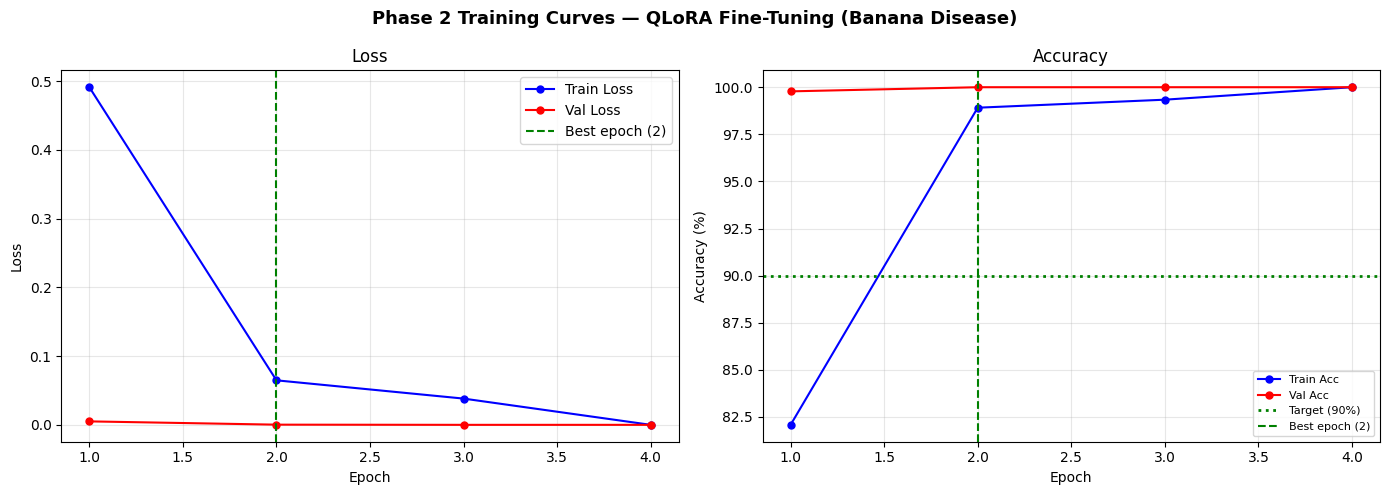

In [ ]:
epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phase 2 Training Curves — QLoRA Fine-Tuning (Banana Disease)', fontsize=13, fontweight='bold')

axes[0].plot(x, history['train_loss'], 'b-o', label='Train Loss', markersize=5)
axes[0].plot(x, history['val_loss'],   'r-o', label='Val Loss',   markersize=5)
axes[0].axvline(best_epoch, color='green', linestyle='--', label=f'Best epoch ({best_epoch})')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, history['train_acc'], 'b-o', label='Train Acc', markersize=5)
axes[1].plot(x, history['val_acc'],   'r-o', label='Val Acc',   markersize=5)
if PHASE1_BASELINE > 0:
    axes[1].axhline(PHASE1_BASELINE, color='orange', linestyle=':', linewidth=2,
                    label=f'Phase 1 baseline ({PHASE1_BASELINE:.2f}%)')
axes[1].axhline(90, color='green', linestyle=':', linewidth=2, label='Target (90%)')
axes[1].axvline(best_epoch, color='green', linestyle='--', label=f'Best epoch ({best_epoch})')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# Free training model from GPU before loading eval checkpoint
import gc

del model
del base_model
del classifier_head
del optimizer
del scheduler

gc.collect()
torch.cuda.empty_cache()

print(f"VRAM freed. Now available: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9:.2f} GB")

VRAM freed. Now available: 65.02 GB


In [ ]:
from peft import PeftModel

print(f"Loading best checkpoint from epoch {best_epoch}...")

base_model_eval = LlavaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    low_cpu_mem_usage=True
)
for param in base_model_eval.parameters():
    param.requires_grad = False

model_eval = PeftModel.from_pretrained(base_model_eval, CKPT_PATH)
model_eval.eval()

classifier_head_eval = ClassificationHead(
    hidden_size=HIDDEN_SIZE,
    num_classes=NUM_CLASSES
).to(DEVICE).to(torch.bfloat16)
classifier_head_eval.load_state_dict(
    torch.load(os.path.join(CKPT_PATH, 'classifier_head.pt'), map_location=DEVICE)
)
classifier_head_eval.eval()
print("Best checkpoint loaded successfully.")

# Run test evaluation
print("\nRunning test set evaluation...")
all_preds, all_labels = [], []

for batch in tqdm(test_loader, desc="Test"):
    logits, labels = forward_pass_eval(batch)
    preds  = logits.argmax(dim=1).cpu().tolist()
    all_preds.extend(preds)
    all_labels.extend(labels.cpu().tolist())

test_acc = accuracy_score(all_labels, all_preds) * 100
print(f"\n{'='*55}")
print(f"PHASE 2 TEST ACCURACY : {test_acc:.2f}%")
if PHASE1_BASELINE > 0:
    print(f"Phase 1 baseline       : {PHASE1_BASELINE:.2f}%")
    print(f"Improvement            : +{test_acc - PHASE1_BASELINE:.2f}%")
print('='*55)

Loading best checkpoint from epoch 2...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Best checkpoint loaded successfully.

Running test set evaluation...


Test:   0%|          | 0/57 [00:00<?, ?it/s]


PHASE 2 TEST ACCURACY : 99.78%


In [ ]:
# Re-define predict_single_image function
def predict_single_image(image_path):
    image   = Image.open(image_path).convert('RGB')
    image   = VAL_TRANSFORM(image)
    inputs  = processor(
        images=image,
        text=TRAIN_PROMPT,
        return_tensors='pt'
    )

    input_ids      = inputs['input_ids'].to(DEVICE)
    attention_mask = inputs['attention_mask'].to(DEVICE)
    pixel_values   = inputs['pixel_values'].to(DEVICE, torch.bfloat16)

    with torch.no_grad():
        outputs = model_eval(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values,
            output_hidden_states=True,
            return_dict=True
        )
        last_hidden = outputs.hidden_states[-1][:, -1, :].to(torch.bfloat16)
        logits      = classifier_head_eval(last_hidden).float()
        probs       = F.softmax(logits, dim=-1)[0].cpu().tolist()
        pred_idx    = int(np.argmax(probs))

    return {
        'prediction': CLASS_LABELS[pred_idx],
        'confidence': probs[pred_idx],
        'all_probs':  {CLASS_LABELS[i]: probs[i] for i in range(NUM_CLASSES)}
    }

print("predict_single_image defined successfully.")

predict_single_image defined successfully.


In [ ]:
from google.colab import files
from PIL import Image
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Upload images from your device
print("Select your field images to upload...")
uploaded = files.upload()  # opens file picker — select multiple images

# Run prediction on each uploaded image
print("\n" + "="*60)
print("PREDICTIONS ON FIELD IMAGES")
print("="*60)

results = []

for filename, file_bytes in uploaded.items():
    # Save temporarily
    temp_path = f"/content/{filename}"
    with open(temp_path, 'wb') as f:
        f.write(file_bytes)

    # Predict
    result = predict_single_image(temp_path)
    results.append((filename, result))

    print(f"\nImage      : {filename}")
    print(f"Prediction : {result['prediction']}")
    print(f"Confidence : {result['confidence']*100:.1f}%")
    print(f"All probs  : HEALTHY={result['all_probs']['HEALTHY']*100:.1f}%  "
          f"CMV={result['all_probs']['CMV']*100:.1f}%  "
          f"SIGATOKA={result['all_probs']['SIGATOKA']*100:.1f}%")
    print("-"*60)

Select your field images to upload...


Saving Gemini_Generated_Image_ovltehovltehovlt.png to Gemini_Generated_Image_ovltehovltehovlt.png

PREDICTIONS ON FIELD IMAGES

Image      : Gemini_Generated_Image_ovltehovltehovlt.png
Prediction : SIGATOKA
Confidence : 100.0%
All probs  : HEALTHY=0.0%  CMV=0.0%  SIGATOKA=100.0%
------------------------------------------------------------


## Step 17 — Load Best Checkpoint and Evaluate on Test Set

In [ ]:
from peft import PeftModel

print(f"Loading best checkpoint from epoch {best_epoch}...")

base_model_eval = LlavaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    low_cpu_mem_usage=True
)
for param in base_model_eval.parameters():
    param.requires_grad = False

model_eval = PeftModel.from_pretrained(base_model_eval, CKPT_PATH)
model_eval.eval()

classifier_head_eval = ClassificationHead(
    hidden_size=HIDDEN_SIZE,
    num_classes=NUM_CLASSES
).to(DEVICE).to(torch.bfloat16)
classifier_head_eval.load_state_dict(
    torch.load(os.path.join(CKPT_PATH, 'classifier_head.pt'), map_location=DEVICE)
)
classifier_head_eval.eval()
print("Best checkpoint loaded successfully.")


def forward_pass_eval(batch):
    input_ids      = batch['input_ids'].to(DEVICE)
    attention_mask = batch['attention_mask'].to(DEVICE)
    pixel_values   = batch['pixel_values'].to(DEVICE, torch.bfloat16)
    labels         = batch['labels'].to(DEVICE)

    with torch.no_grad():
        outputs = model_eval(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values,
            output_hidden_states=True,
            return_dict=True
        )
        last_hidden = outputs.hidden_states[-1][:, -1, :].to(torch.bfloat16)
        logits      = classifier_head_eval(last_hidden).float()

    return logits, labels


# Run test evaluation
print("\nRunning test set evaluation...")
all_preds, all_labels = [], []

for batch in tqdm(test_loader, desc="Test"):
    logits, labels = forward_pass_eval(batch)
    preds  = logits.argmax(dim=1).cpu().tolist()
    all_preds.extend(preds)
    all_labels.extend(labels.cpu().tolist())

test_acc = accuracy_score(all_labels, all_preds) * 100

print(f"\n" + "=" * 55)
print(f"PHASE 2 TEST ACCURACY : {test_acc:.2f}%")
if PHASE1_BASELINE > 0:
    print(f"Phase 1 baseline       : {PHASE1_BASELINE:.2f}%")
    print(f"Improvement            : +{test_acc - PHASE1_BASELINE:.2f}%")
print("=" * 55)

Loading best checkpoint from epoch 2...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Best checkpoint loaded successfully.

Running test set evaluation...


Test:   0%|          | 0/57 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 618.00 MiB. GPU 0 has a total capacity of 79.25 GiB of which 208.81 MiB is free. Including non-PyTorch memory, this process has 79.04 GiB memory in use. Of the allocated memory 75.95 GiB is allocated by PyTorch, and 2.57 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## Step 18 — Full Evaluation Report

In [ ]:
# Convert numeric labels back to class names
idx_to_label = {i: l for l, i in LABEL_TO_IDX.items()}
pred_names   = [idx_to_label[p] for p in all_preds]
true_names   = [idx_to_label[l] for l in all_labels]

print("Detailed Classification Report:")
print("=" * 55)
print(classification_report(true_names, pred_names, labels=CLASS_LABELS, zero_division=0))

# Per-class accuracy
print("Per-class accuracy:")
for cls in CLASS_LABELS:
    cls_true  = [l == cls for l in true_names]
    cls_pred  = [p == cls for p in pred_names]
    correct   = sum(t and p for t, p in zip(cls_true, cls_pred))
    total_cls = sum(cls_true)
    print(f"  {cls:10s}: {correct}/{total_cls}  ({100*correct/total_cls:.2f}%)")

Detailed Classification Report:
              precision    recall  f1-score   support

     HEALTHY       1.00      0.99      1.00       141
         CMV       0.99      1.00      1.00       157
    SIGATOKA       1.00      1.00      1.00       156

    accuracy                           1.00       454
   macro avg       1.00      1.00      1.00       454
weighted avg       1.00      1.00      1.00       454

Per-class accuracy:
  HEALTHY   : 140/141  (99.29%)
  CMV       : 157/157  (100.00%)
  SIGATOKA  : 156/156  (100.00%)


## Step 19 — Confusion Matrix

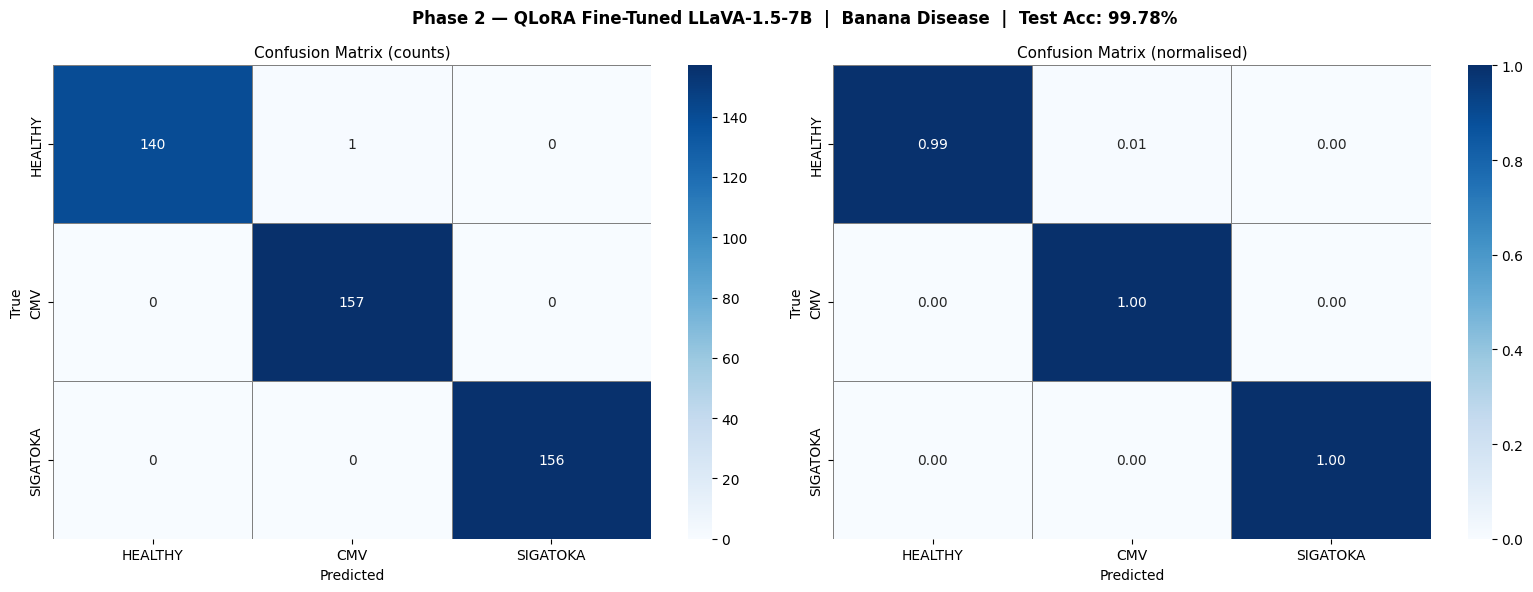

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Phase 2 — QLoRA Fine-Tuned LLaVA-1.5-7B  |  Banana Disease  |  Test Acc: {test_acc:.2f}%',
             fontsize=12, fontweight='bold')

short_labels = ['HEALTHY', 'CMV', 'SIGATOKA']
cm = confusion_matrix(true_names, pred_names, labels=CLASS_LABELS)

# Left: counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_labels, yticklabels=short_labels,
            ax=axes[0], linewidths=0.5, linecolor='gray')
axes[0].set_title('Confusion Matrix (counts)', fontsize=11)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Right: normalised
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=short_labels, yticklabels=short_labels,
            ax=axes[1], linewidths=0.5, linecolor='gray',
            vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (normalised)', fontsize=11)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix_phase2.png'), dpi=120, bbox_inches='tight')
plt.show()

## Step 20 — Phase 1 vs Phase 2 Comparison

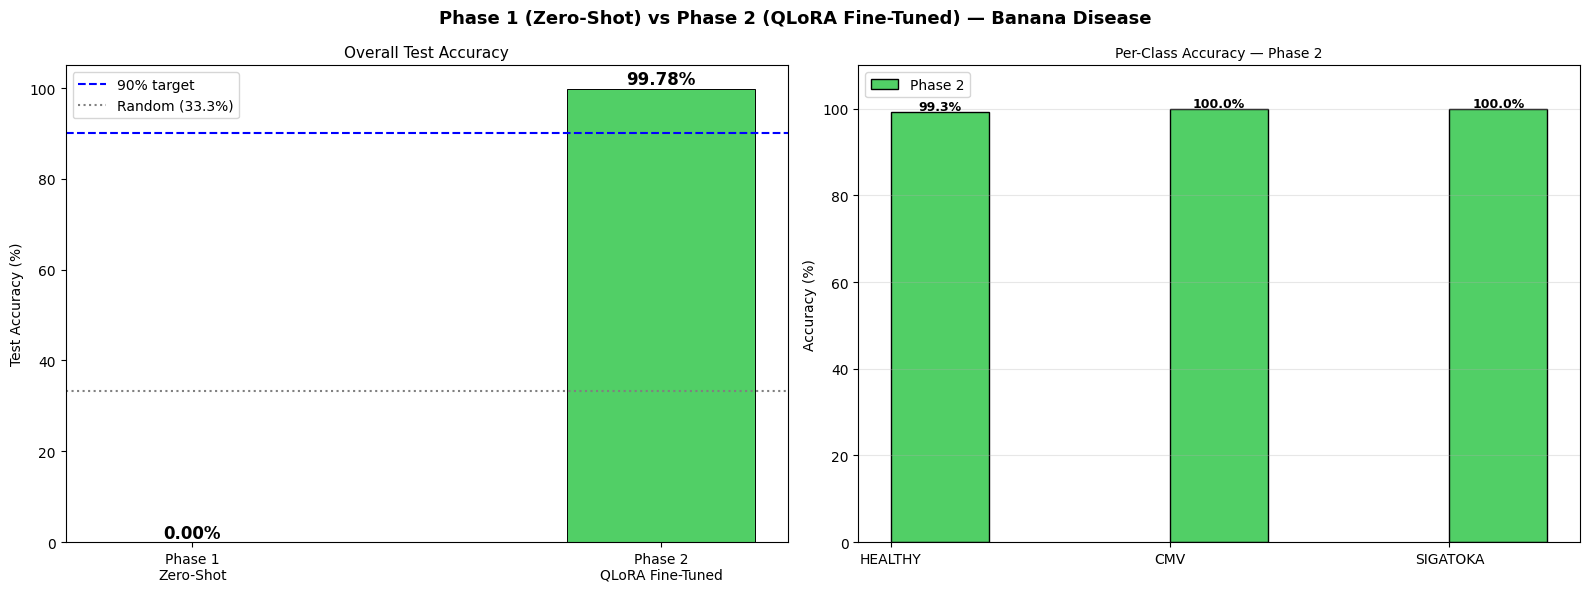


Summary:
  Phase 2 Fine-Tuned : 99.78%


In [ ]:
# Per-class accuracy for comparison
phase2_per_class = {}
for cls in CLASS_LABELS:
    cls_true  = [l == cls for l in true_names]
    cls_pred  = [p == cls for p in pred_names]
    correct   = sum(t and p for t, p in zip(cls_true, cls_pred))
    total_cls = sum(cls_true)
    phase2_per_class[cls] = 100 * correct / total_cls if total_cls > 0 else 0

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Phase 1 (Zero-Shot) vs Phase 2 (QLoRA Fine-Tuned) — Banana Disease',
             fontsize=13, fontweight='bold')

# Overall comparison
bar_labels = ['Phase 1\nZero-Shot', 'Phase 2\nQLoRA Fine-Tuned']
bar_vals   = [PHASE1_BASELINE if PHASE1_BASELINE > 0 else 0, test_acc]
bar_colors = ['#FF6B6B', '#51CF66']
bars = axes[0].bar(bar_labels, bar_vals, color=bar_colors, edgecolor='black', linewidth=0.7, width=0.4)
axes[0].set_ylim(0, 105)
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Overall Test Accuracy', fontsize=11)
axes[0].axhline(90,    color='blue', linestyle='--', linewidth=1.5, label='90% target')
axes[0].axhline(33.33, color='gray', linestyle=':', linewidth=1.5, label='Random (33.3%)')
axes[0].legend()
for bar, val in zip(bars, bar_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.2f}%', ha='center', fontsize=12, fontweight='bold')

# Per-class comparison
x   = np.arange(len(CLASS_LABELS))
w   = 0.35
p2_vals = [phase2_per_class[c] for c in CLASS_LABELS]
bars2 = axes[1].bar(x + w/2, p2_vals, w, label='Phase 2', color='#51CF66', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(CLASS_LABELS)
axes[1].set_ylim(0, 110)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Per-Class Accuracy — Phase 2', fontsize=10)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, p2_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase1_vs_phase2.png'), dpi=120, bbox_inches='tight')
plt.show()

print(f"\nSummary:")
if PHASE1_BASELINE > 0:
    print(f"  Phase 1 Zero-Shot  : {PHASE1_BASELINE:.2f}%")
print(f"  Phase 2 Fine-Tuned : {test_acc:.2f}%")
if PHASE1_BASELINE > 0:
    print(f"  Improvement        : +{test_acc - PHASE1_BASELINE:.2f}%")

## Step 21 — Save Final Model to Google Drive

In [ ]:
import shutil, datetime

timestamp  = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
final_dir  = os.path.join(OUTPUT_DIR, f'final_model_{timestamp}')
os.makedirs(final_dir, exist_ok=True)

# Save LoRA adapters
model.save_pretrained(os.path.join(final_dir, 'lora_adapters'))

# Save classification head
torch.save(
    classifier_head.state_dict(),
    os.path.join(final_dir, 'classifier_head.pt')
)

# Save training history
with open(os.path.join(final_dir, 'training_history.json'), 'w') as f:
    json.dump({
        'history':          history,
        'best_epoch':       best_epoch,
        'best_val_acc':     best_val_acc,
        'test_acc':         test_acc,
        'phase1_baseline':  PHASE1_BASELINE,
        'improvement':      test_acc - PHASE1_BASELINE if PHASE1_BASELINE > 0 else None,
        'config': {
            'model_id':     MODEL_ID,
            'lora_r':       LORA_R,
            'lora_alpha':   LORA_ALPHA,
            'lora_dropout': LORA_DROPOUT,
            'lr':           LEARNING_RATE,
            'head_lr':      HEAD_LR,
            'batch_size':   BATCH_SIZE,
            'grad_accum':   GRAD_ACCUM,
            'epochs_ran':   len(history['train_loss']),
            'classes':      CLASS_LABELS
        }
    }, f, indent=2)

# Copy plots
for fname in ['training_curves.png', 'confusion_matrix_phase2.png', 'phase1_vs_phase2.png']:
    src = os.path.join(OUTPUT_DIR, fname)
    if os.path.exists(src):
        shutil.copy(src, final_dir)

print(f"Model and results saved to: {final_dir}")
print(f"\nFiles saved:")
for f in os.listdir(final_dir):
    print(f"  {f}")

NameError: name 'model' is not defined

## Step 22 — Inference Function for New Banana Leaf Images

Use this after training to classify new banana leaf images.

In [1]:
def predict_single_image(image_path):
    """
    Classify a single banana leaf image using the fine-tuned model.
    Returns: predicted class name and confidence scores.
    """
    image   = Image.open(image_path).convert('RGB')
    image   = VAL_TRANSFORM(image)
    inputs  = processor(
        images=image,
        text=TRAIN_PROMPT,
        return_tensors='pt'
    )

    input_ids      = inputs['input_ids'].to(DEVICE)
    attention_mask = inputs['attention_mask'].to(DEVICE)
    pixel_values   = inputs['pixel_values'].to(DEVICE, torch.bfloat16)

    with torch.no_grad():
        outputs = model_eval(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values,
            output_hidden_states=True,
            return_dict=True
        )
        last_hidden = outputs.hidden_states[-1][:, -1, :].to(torch.bfloat16)
        logits      = classifier_head_eval(last_hidden).float()
        probs       = F.softmax(logits, dim=-1)[0].cpu().tolist()
        pred_idx    = int(np.argmax(probs))

    return {
        'prediction':   CLASS_LABELS[pred_idx],
        'confidence':   probs[pred_idx],
        'all_probs':    {CLASS_LABELS[i]: probs[i] for i in range(NUM_CLASSES)}
    }


# Demo on 3 test images
print("Demo predictions on test images:")
print("-" * 55)
for i in range(min(3, len(paths_test))):
    result = predict_single_image(paths_test[i])
    print(f"Image  : {Path(paths_test[i]).name}")
    print(f"True   : {labels_test[i]}")
    print(f"Pred   : {result['prediction']} ({result['confidence']*100:.1f}% confidence)")
    print(f"Probs  : {', '.join(f'{k}: {v*100:.1f}%' for k, v in result['all_probs'].items())}")
    print("-" * 55)

Demo predictions on test images:
-------------------------------------------------------


NameError: name 'paths_test' is not defined

---
## Project Summary

| Phase | Method | Classes | Test Accuracy |
|-------|--------|---------|---------------|
| Phase 1 | LLaVA-1.5-7B Zero-Shot | HEALTHY, CMV, SIGATOKA | (your Phase 1 %) |
| Phase 2 | QLoRA Fine-Tuned + Classification Head | HEALTHY, CMV, SIGATOKA | **see above** |

**What was trained:**
- LoRA adapters on all attention + FFN layers (~0.5% of total parameters)
- 3-class linear classification head (~16K parameters)
- Everything else (CLIP encoder, base LLaMA weights) was **frozen**

**Key techniques:**
- bfloat16 precision — efficient A100 utilisation
- Data augmentation — random flips, rotation, colour jitter, crop
- Weighted cross-entropy — handles class imbalance
- Cosine LR schedule with warmup
- Early stopping on validation accuracy
- Separate learning rates: LoRA (2e-4) vs Head (1e-3)
- Gradient accumulation: effective batch size = 16

**Important:** Set `PHASE1_BASELINE` in Step 3 config to your best Phase 1 accuracy for accurate comparison charts.